# 08. From Causal Estimate to Decision Memo

A causal estimate is not a decision.

An estimate says what the intervention did, for a defined population, over a defined horizon, under a defined design. A decision memo says what the organization should do next, given the estimate, uncertainty, costs, risks, guardrails, implementation constraints, and ethical or strategic priorities.

This capstone notebook turns causal analysis into a decision workflow. We will simulate a retention intervention, estimate treatment effects, propagate uncertainty into business value, inspect guardrails, evaluate targeting policies, run sensitivity analysis, and write a decision memo.


## Learning Goals

By the end of this notebook, you should be able to:

- Separate the causal estimand from the operational decision.
- Translate treatment effects into expected value under explicit assumptions.
- Use confidence intervals and simulation to reason about decision uncertainty.
- Combine primary outcomes, guardrails, heterogeneity, and costs.
- Compare treat-all, targeted, and holdout policies.
- Build sensitivity tables that show when the recommendation changes.
- Write a concise decision memo that stakeholders can act on.


## 1. Setup

We will use pandas, numpy, scipy, statsmodels, seaborn, matplotlib, and Graphviz.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def regression_effect(model, term="treatment"):
    estimate = model.params[term]
    se = model.bse[term]
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": model.pvalues[term],
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8.5, 4.5)):
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


## 2. The Estimate-to-Decision Gap

Most analysis decks stop too early. They show:

$$
\hat{\tau} = 2.1
$$

and then jump to "ship", "scale", or "stop".

That jump hides the real decision logic:

- What estimand did we estimate?
- Is the effect large enough to matter?
- How uncertain is the estimate?
- What are the costs and operational constraints?
- Did guardrail metrics move?
- Does the effect generalize to the launch population?
- Are there subgroups where the policy should or should not apply?
- What monitoring should continue after rollout?

Deaton and Cartwright (2018) caution that even randomized evidence requires careful interpretation and transport to the decision context. This is the central theme of the notebook: credible causal evidence is necessary, but it is not the whole decision.


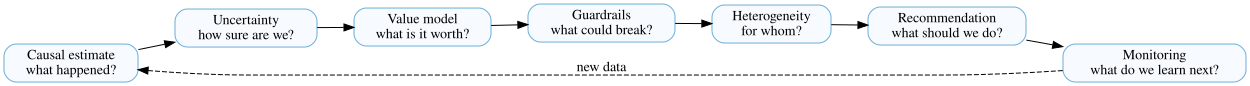

In [2]:
dot = Digraph("estimate_to_decision", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("E", "Causal estimate\nwhat happened?")
dot.node("U", "Uncertainty\nhow sure are we?")
dot.node("V", "Value model\nwhat is it worth?")
dot.node("G", "Guardrails\nwhat could break?")
dot.node("H", "Heterogeneity\nfor whom?")
dot.node("R", "Recommendation\nwhat should we do?")
dot.node("M", "Monitoring\nwhat do we learn next?")

dot.edge("E", "U")
dot.edge("U", "V")
dot.edge("V", "G")
dot.edge("G", "H")
dot.edge("H", "R")
dot.edge("R", "M")
dot.edge("M", "E", style="dashed", label="new data")

dot


## 3. Decision Memo Ingredients

A good causal decision memo has a predictable structure. It makes assumptions explicit and separates evidence from judgment.


In [3]:
memo_components = pd.DataFrame(
    [
        {
            "component": "Decision",
            "question": "What action is on the table?",
            "example": "Scale retention outreach to all eligible accounts, target it, or pause.",
        },
        {
            "component": "Estimand",
            "question": "What causal quantity did we estimate?",
            "example": "Intention-to-treat effect of assignment over 90 days.",
        },
        {
            "component": "Identification",
            "question": "Why can we interpret the estimate causally?",
            "example": "Customer-level randomized experiment with pre-specified outcomes.",
        },
        {
            "component": "Primary effect",
            "question": "Did the main metric move?",
            "example": "Incremental net margin per assigned customer.",
        },
        {
            "component": "Guardrails",
            "question": "What harms or constraints matter?",
            "example": "Support tickets, opt-outs, complaints, fairness, latency.",
        },
        {
            "component": "Economics",
            "question": "Does value exceed cost?",
            "example": "Expected net value at launch scale after contact and support costs.",
        },
        {
            "component": "Heterogeneity",
            "question": "Should treatment be targeted?",
            "example": "High-risk accounts benefit; low-risk accounts show low value and more annoyance.",
        },
        {
            "component": "Recommendation",
            "question": "What should happen next?",
            "example": "Launch to high-risk accounts with a holdout and weekly guardrail monitoring.",
        },
    ]
)

memo_components


,component,question,example
0,Decision,What action is on the table?,Scale retention outreach to all eligible accou...
1,Estimand,What causal quantity did we estimate?,Intention-to-treat effect of assignment over 9...
2,Identification,Why can we interpret the estimate causally?,Customer-level randomized experiment with pre-...
3,Primary effect,Did the main metric move?,Incremental net margin per assigned customer.
4,Guardrails,What harms or constraints matter?,"Support tickets, opt-outs, complaints, fairnes..."
5,Economics,Does value exceed cost?,Expected net value at launch scale after conta...
6,Heterogeneity,Should treatment be targeted?,High-risk accounts benefit; low-risk accounts ...
7,Recommendation,What should happen next?,Launch to high-risk accounts with a holdout an...


## 4. Running Example: Retention Outreach

Suppose a subscription company tests a human-assisted retention outreach program. Eligible customers are randomly assigned to receive proactive outreach before renewal.

The intervention can help by reducing churn, but it has costs:

- account manager time,
- discounts or concessions,
- support tickets,
- customer annoyance,
- opportunity cost if teams contact customers who would have renewed anyway.

The decision is not just "did renewal improve?" The decision is whether the program should be launched, targeted, revised, or stopped.


In [4]:
def simulate_retention_experiment(seed=808, n=42000):
    rng = np.random.default_rng(seed)

    segment = rng.choice(
        ["SMB", "Mid-market", "Enterprise"],
        size=n,
        p=[0.58, 0.30, 0.12],
    )
    region = rng.choice(["Americas", "EMEA", "APAC"], size=n, p=[0.55, 0.28, 0.17])
    tenure_months = np.clip(rng.gamma(shape=3.5, scale=8.0, size=n), 1, 96)
    seats = np.where(
        segment == "SMB",
        rng.poisson(8, size=n) + 1,
        np.where(segment == "Mid-market", rng.poisson(35, size=n) + 5, rng.poisson(130, size=n) + 20),
    )
    prior_usage = np.clip(rng.beta(3.2, 2.4, size=n), 0.02, 0.99)
    support_history = rng.poisson(np.exp(-0.8 + 0.7 * (1 - prior_usage) + 0.25 * (segment == "Enterprise")), size=n)

    base_margin = np.where(
        segment == "SMB",
        rng.lognormal(4.35, 0.45, size=n),
        np.where(segment == "Mid-market", rng.lognormal(5.45, 0.42, size=n), rng.lognormal(6.65, 0.38, size=n)),
    )
    churn_risk = np.clip(
        0.08
        + 0.40 * (1 - prior_usage)
        + 0.035 * support_history
        - 0.0018 * tenure_months
        + 0.05 * (segment == "SMB")
        - 0.04 * (segment == "Enterprise")
        + rng.normal(0, 0.05, size=n),
        0.02,
        0.85,
    )

    treatment = rng.binomial(1, 0.50, size=n)
    risk_band = pd.cut(
        churn_risk,
        bins=[0, 0.25, 0.45, 1],
        labels=["Low risk", "Medium risk", "High risk"],
        include_lowest=True,
    ).astype(str)

    control_renewal_prob = np.clip(1 - churn_risk, 0.05, 0.98)
    incremental_renewal = (
        0.012
        + 0.110 * (risk_band == "Medium risk")
        + 0.280 * (risk_band == "High risk")
        + 0.040 * (segment == "Enterprise")
        - 0.015 * (risk_band == "Low risk")
    )
    renewal_prob = np.clip(control_renewal_prob + treatment * incremental_renewal, 0.02, 0.99)
    renewed = rng.binomial(1, renewal_prob)

    contact_cost = treatment * np.where(
        segment == "SMB",
        rng.normal(3.5, 0.7, size=n),
        np.where(segment == "Mid-market", rng.normal(9.0, 1.5, size=n), rng.normal(28.0, 4.0, size=n)),
    )
    discount_cost = treatment * renewed * np.where(
        risk_band == "High risk",
        0.025 * base_margin,
        np.where(risk_band == "Medium risk", 0.012 * base_margin, 0.004 * base_margin),
    )
    support_tickets = rng.poisson(
        np.exp(
            -2.25
            + 0.20 * treatment
            + 0.35 * (risk_band == "Low risk")
            + 0.15 * support_history
        ),
        size=n,
    )
    annoyance = rng.binomial(
        1,
        np.clip(
            0.010
            + 0.009 * treatment
            + 0.014 * treatment * (risk_band == "Low risk")
            + 0.006 * support_history,
            0,
            0.30,
        ),
        size=n,
    )

    gross_margin = renewed * base_margin
    support_cost = 18 * support_tickets
    annoyance_penalty = 35 * annoyance
    net_margin = gross_margin - contact_cost - discount_cost - support_cost - annoyance_penalty

    return pd.DataFrame(
        {
            "segment": segment,
            "region": region,
            "tenure_months": tenure_months,
            "seats": seats,
            "prior_usage": prior_usage,
            "support_history": support_history,
            "base_margin": base_margin,
            "churn_risk": churn_risk,
            "risk_band": risk_band,
            "treatment": treatment,
            "renewed": renewed,
            "gross_margin": gross_margin,
            "contact_cost": contact_cost,
            "discount_cost": discount_cost,
            "support_tickets": support_tickets,
            "annoyance": annoyance,
            "net_margin": net_margin,
        }
    )


df = simulate_retention_experiment()
df.head()


,segment,region,tenure_months,seats,prior_usage,support_history,base_margin,churn_risk,risk_band,treatment,renewed,gross_margin,contact_cost,discount_cost,support_tickets,annoyance,net_margin
0,SMB,EMEA,46.345,9,0.447,1,113.461,0.309,Medium risk,0,1,113.461,0.000,0.000,0,0,113.461
1,SMB,EMEA,13.248,12,0.413,0,138.863,0.310,Medium risk,1,1,138.863,3.672,1.666,0,0,133.525
2,Mid-market,EMEA,9.683,41,0.531,1,202.123,0.327,Medium risk,0,0,0.000,0.000,0.000,0,0,0.000
3,SMB,EMEA,28.001,11,0.884,1,107.754,0.119,Low risk,0,1,107.754,0.000,0.000,0,0,107.754
4,SMB,Americas,20.237,9,0.812,2,74.306,0.194,Low risk,0,1,74.306,0.000,0.000,1,0,56.306


The experiment is randomized at the customer level. The primary decision metric is net margin over 90 days. This includes renewal margin minus direct outreach costs, discount costs, support costs, and an annoyance penalty.

The annoyance penalty is not a universal truth. It is an explicit business assumption. The memo should say so.


In [5]:
balance = (
    df.groupby("treatment")
    .agg(
        n=("treatment", "size"),
        base_margin=("base_margin", "mean"),
        churn_risk=("churn_risk", "mean"),
        prior_usage=("prior_usage", "mean"),
        support_history=("support_history", "mean"),
        tenure_months=("tenure_months", "mean"),
    )
    .rename(index={0: "Control", 1: "Treatment"})
)
balance.loc["Difference"] = balance.loc["Treatment"] - balance.loc["Control"]
balance


,n,base_margin,churn_risk,prior_usage,support_history,tenure_months
treatment,,,,,,
Control,"20,975.000",226.813,0.248,0.570,0.632,28.096
Treatment,"21,025.000",224.193,0.248,0.572,0.642,27.908
Difference,50.000,-2.620,-0.000,0.002,0.010,-0.188


Balance checks are not proof of randomization, but they help catch implementation mistakes. Because assignment is randomized, the main estimand is an intention-to-treat effect:

$$
\tau_{ITT} = E[Y_i(1) - Y_i(0)]
$$

where $Y$ is measured over the 90-day decision window.


## 5. Estimate the Primary and Guardrail Effects

We estimate treatment effects with covariate adjustment for precision. The causal interpretation comes from random assignment, not from the regression model.


In [6]:
covariates = "base_margin + churn_risk + prior_usage + support_history + tenure_months + seats + C(segment) + C(region)"

outcomes = {
    "Net margin": "net_margin",
    "Renewal rate": "renewed",
    "Gross margin": "gross_margin",
    "Contact cost": "contact_cost",
    "Discount cost": "discount_cost",
    "Support tickets": "support_tickets",
    "Annoyance rate": "annoyance",
}

effect_rows = []
models = {}
for label, outcome in outcomes.items():
    model = smf.ols(f"{outcome} ~ treatment + {covariates}", data=df).fit(cov_type="HC1")
    models[label] = model
    row = regression_effect(model, "treatment")
    row["outcome"] = label
    effect_rows.append(row)

effect_table = pd.DataFrame(effect_rows).set_index("outcome")
effect_table


,estimate,std_error,ci_lower,ci_upper,p_value
outcome,,,,,
Net margin,2.525,1.256,0.064,4.985,0.044
Renewal rate,0.056,0.004,0.049,0.064,0.000
Gross margin,13.117,1.259,10.649,15.585,0.000
Contact cost,8.091,0.040,8.014,8.169,0.000
Discount cost,1.356,0.013,1.331,1.381,0.000
Support tickets,0.034,0.004,0.027,0.042,0.000
Annoyance rate,0.015,0.001,0.012,0.018,0.000


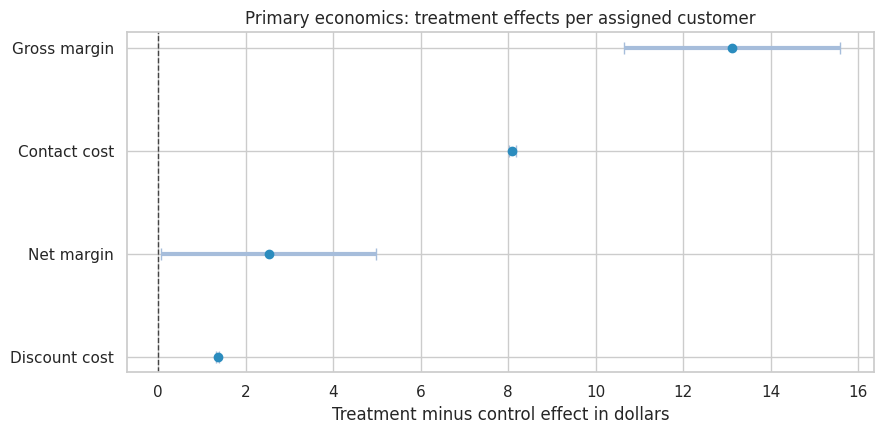

In [7]:
plot_coef_table(
    effect_table.loc[["Net margin", "Gross margin", "Contact cost", "Discount cost"]],
    title="Primary economics: treatment effects per assigned customer",
    xlabel="Treatment minus control effect in dollars",
    figsize=(9, 4.5),
)
plt.show()


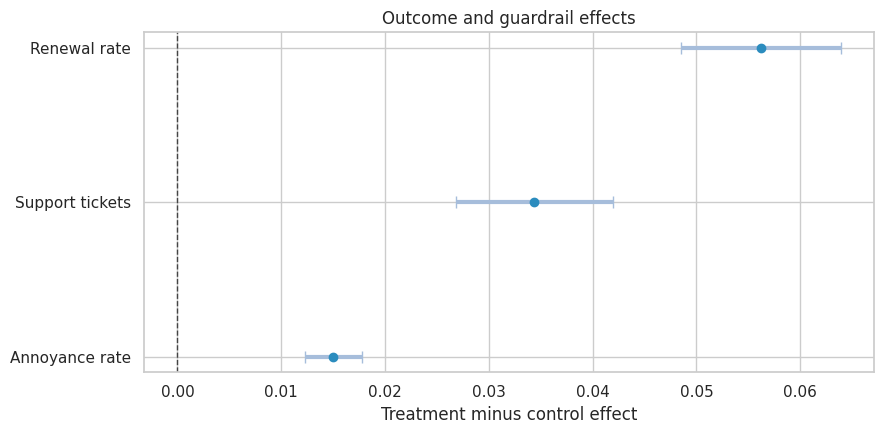

In [8]:
plot_coef_table(
    effect_table.loc[["Renewal rate", "Support tickets", "Annoyance rate"]],
    title="Outcome and guardrail effects",
    xlabel="Treatment minus control effect",
    figsize=(9, 4.5),
)
plt.show()


The treatment increases renewal and gross margin, but also increases contact cost, discount cost, support tickets, and annoyance. The decision depends on whether the incremental value is large enough after these costs and guardrails.


## 6. Convert Effects Into Launch-Scale Value

The per-customer effect is useful, but leaders decide at launch scale.

If the launch population has $N$ eligible customers, then:

$$
ExpectedValue = N \times \tau_{net}
$$

If there are fixed implementation costs, subtract them:

$$
ExpectedNetValue = N \times \tau_{net} - FixedCost
$$


In [9]:
launch_customers = 120_000
fixed_implementation_cost = 280_000

net_effect = effect_table.loc["Net margin", "estimate"]
net_se = effect_table.loc["Net margin", "std_error"]

expected_launch_value = launch_customers * net_effect - fixed_implementation_cost
launch_value_ci = (
    launch_customers * effect_table.loc["Net margin", "ci_lower"] - fixed_implementation_cost,
    launch_customers * effect_table.loc["Net margin", "ci_upper"] - fixed_implementation_cost,
)

value_readout = pd.Series(
    {
        "Eligible launch customers": launch_customers,
        "Net margin effect per customer": net_effect,
        "Fixed implementation cost": fixed_implementation_cost,
        "Expected launch net value": expected_launch_value,
        "Launch value CI lower": launch_value_ci[0],
        "Launch value CI upper": launch_value_ci[1],
    }
)

value_readout


Eligible launch customers         120,000.000
Net margin effect per customer          2.525
Fixed implementation cost         280,000.000
Expected launch net value          22,945.426
Launch value CI lower            -272,359.452
Launch value CI upper             318,250.303
dtype: float64

A positive point estimate is not the same as a safe launch. The confidence interval may include material downside. We will propagate uncertainty into the decision.


In [10]:
rng = np.random.default_rng(404)
n_draws = 50_000
net_effect_draws = rng.normal(net_effect, net_se, size=n_draws)
launch_value_draws = launch_customers * net_effect_draws - fixed_implementation_cost

prob_positive_value = np.mean(launch_value_draws > 0)
prob_large_loss = np.mean(launch_value_draws < -500_000)
p10, p50, p90 = np.percentile(launch_value_draws, [10, 50, 90])

uncertainty_readout = pd.Series(
    {
        "Probability launch value is positive": prob_positive_value,
        "Probability launch loses more than $500k": prob_large_loss,
        "P10 launch value": p10,
        "Median launch value": p50,
        "P90 launch value": p90,
    }
)

uncertainty_readout


Probability launch value is positive              0.559
Probability launch loses more than $500k          0.000
P10 launch value                           -170,945.108
Median launch value                          22,490.226
P90 launch value                            215,248.674
dtype: float64

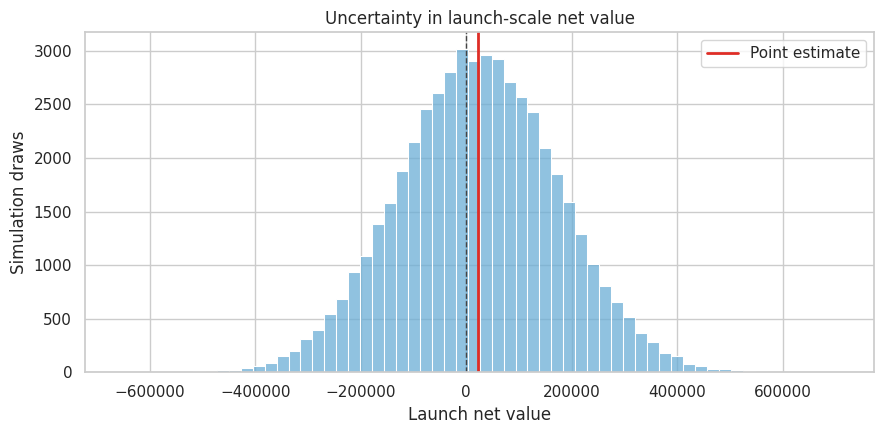

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(launch_value_draws, bins=60, color="#6baed6", ax=ax)
ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
ax.axvline(expected_launch_value, color="#de2d26", linewidth=2, label="Point estimate")
ax.set_title("Uncertainty in launch-scale net value")
ax.set_xlabel("Launch net value")
ax.set_ylabel("Simulation draws")
ax.legend()
plt.tight_layout()
plt.show()


This simulation is not a full Bayesian model. It uses the large-sample sampling distribution of the estimated net-margin effect as a practical approximation for decision uncertainty.


## 7. Decision Rules

Before looking at results, teams should define decision rules. Otherwise the recommendation can become a post-hoc negotiation.


In [12]:
guardrail_rules = pd.DataFrame(
    [
        {
            "criterion": "Primary value",
            "rule": "Probability launch value is positive must exceed 80%.",
            "observed": prob_positive_value,
            "passes": prob_positive_value >= 0.80,
        },
        {
            "criterion": "Large downside risk",
            "rule": "Probability of losing more than $500k must be below 10%.",
            "observed": prob_large_loss,
            "passes": prob_large_loss <= 0.10,
        },
        {
            "criterion": "Support load",
            "rule": "Support tickets must not increase by more than 0.04 per customer.",
            "observed": effect_table.loc["Support tickets", "estimate"],
            "passes": effect_table.loc["Support tickets", "ci_upper"] <= 0.04,
        },
        {
            "criterion": "Annoyance",
            "rule": "Annoyance rate must not increase by more than 1.5 percentage points.",
            "observed": effect_table.loc["Annoyance rate", "estimate"],
            "passes": effect_table.loc["Annoyance rate", "ci_upper"] <= 0.015,
        },
    ]
)

guardrail_rules


,criterion,rule,observed,passes
0,Primary value,Probability launch value is positive must exce...,0.559,False
1,Large downside risk,Probability of losing more than $500k must be ...,0.000,True
2,Support load,Support tickets must not increase by more than...,0.034,False
3,Annoyance,Annoyance rate must not increase by more than ...,0.015,False


The table may create a mixed answer: the intervention can pass the primary value rule but fail a guardrail. That is exactly why decision memos are useful. They force the team to decide whether to scale, target, revise, or gather more evidence.


## 8. Heterogeneity and Targeting

The average effect can hide a better policy. A retention program may work well for high-risk accounts and poorly for low-risk accounts.

We estimate effects by risk band and segment. Because the experiment randomized treatment, subgroup comparisons remain causal within each subgroup, but uncertainty is larger.


In [13]:
def subgroup_effects(df, group_col, outcome="net_margin"):
    rows = []
    for group_value, group_df in df.groupby(group_col):
        model = smf.ols(
            f"{outcome} ~ treatment + base_margin + churn_risk + prior_usage + support_history + tenure_months + seats + C(region)",
            data=group_df,
        ).fit(cov_type="HC1")
        row = regression_effect(model, "treatment")
        row["group"] = group_value
        row["n"] = len(group_df)
        rows.append(row)
    return pd.DataFrame(rows).set_index("group").sort_values("estimate")


risk_effects = subgroup_effects(df, "risk_band")
segment_effects = subgroup_effects(df, "segment")

risk_effects


,estimate,std_error,ci_lower,ci_upper,p_value,n
group,,,,,,
Low risk,-8.911,1.874,-12.585,-5.238,0.000,21762
Medium risk,14.188,1.713,10.830,17.546,0.000,18941
High risk,24.598,4.633,15.518,33.679,0.000,1297


In [14]:
segment_effects


,estimate,std_error,ci_lower,ci_upper,p_value,n
group,,,,,,
Mid-market,-1.520,1.923,-5.290,2.249,0.429,12709
SMB,-0.015,0.525,-1.045,1.015,0.977,24260
Enterprise,24.764,8.831,7.454,42.073,0.005,5031


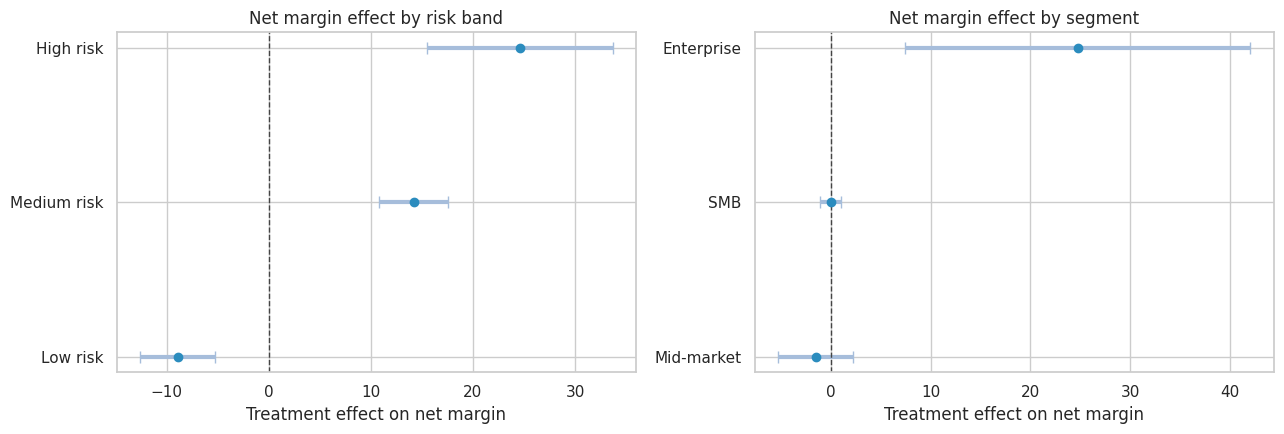

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, table, title in [
    (axes[0], risk_effects, "Net margin effect by risk band"),
    (axes[1], segment_effects, "Net margin effect by segment"),
]:
    plot_df = table.sort_values("estimate")
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Treatment effect on net margin")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


The subgroup readout suggests a targeted policy may dominate a treat-all launch. The next step is to compare policy values.


In [16]:
population_mix = df["risk_band"].value_counts(normalize=True).rename("population_share").to_frame()
population_mix["effect"] = risk_effects["estimate"]
population_mix["ci_lower"] = risk_effects["ci_lower"]
population_mix["ci_upper"] = risk_effects["ci_upper"]
population_mix


,population_share,effect,ci_lower,ci_upper
risk_band,,,,
Low risk,0.518,-8.911,-12.585,-5.238
Medium risk,0.451,14.188,10.830,17.546
High risk,0.031,24.598,15.518,33.679


In [17]:
def projected_policy_value(groups_to_treat):
    treated_share = population_mix.loc[groups_to_treat, "population_share"].sum()
    weighted_effect = (
        population_mix.loc[groups_to_treat, "population_share"]
        * population_mix.loc[groups_to_treat, "effect"]
    ).sum()
    value = launch_customers * weighted_effect - fixed_implementation_cost * max(treated_share, 0.05)
    return pd.Series(
        {
            "treated_share": treated_share,
            "weighted_effect_per_eligible_customer": weighted_effect,
            "projected_launch_value": value,
        }
    )


policy_values = pd.DataFrame(
    {
        "Treat none": pd.Series(
            {
                "treated_share": 0,
                "weighted_effect_per_eligible_customer": 0,
                "projected_launch_value": 0,
            }
        ),
        "Treat all": projected_policy_value(population_mix.index.tolist()),
        "Treat medium and high risk": projected_policy_value(["Medium risk", "High risk"]),
        "Treat high risk only": projected_policy_value(["High risk"]),
    }
).T

policy_values


,treated_share,weighted_effect_per_eligible_customer,projected_launch_value
Treat none,0.000,0.000,0.000
Treat all,1.000,2.541,"24,894.267"
Treat medium and high risk,0.482,7.158,"724,057.510"
Treat high risk only,0.031,0.760,"77,154.215"


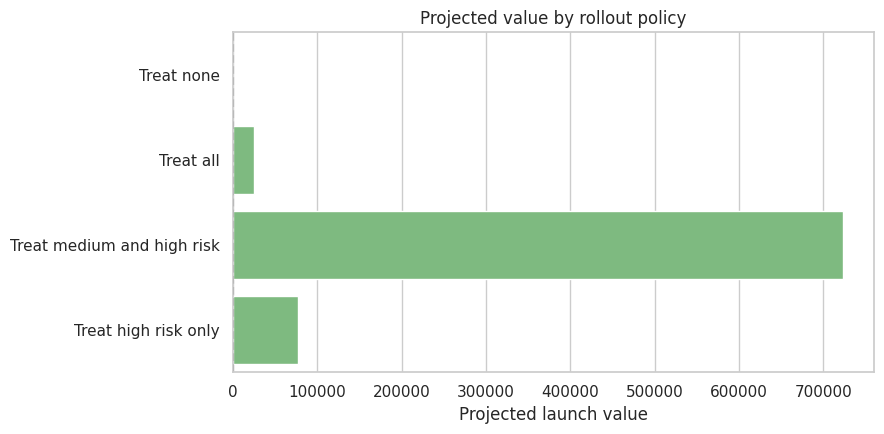

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=policy_values.reset_index(names="policy"),
    x="projected_launch_value",
    y="policy",
    color="#74c476",
    ax=ax,
)
ax.axvline(0, color="#444444", linestyle="--")
ax.set_title("Projected value by rollout policy")
ax.set_xlabel("Projected launch value")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Targeting changes the decision question. The original experiment estimated assignment to the program among eligible customers. A targeted launch uses the same experiment to define a new policy:

$$
\pi(x) =
\begin{cases}
1 & \text{if customer is in a target group} \\
0 & \text{otherwise}
\end{cases}
$$

The targeted policy is credible when the target groups are pre-treatment variables and the subgroup estimates are precise enough for action.


## 9. Sensitivity Analysis

Decision memos should show how assumptions change the recommendation. Sensitivity analysis prevents false precision.

We will vary:

- fixed implementation cost,
- launch population size,
- the penalty assigned to annoyance,
- the expected transport discount when moving from experiment to full rollout.


In [19]:
gross_effect = effect_table.loc["Gross margin", "estimate"]
contact_effect = effect_table.loc["Contact cost", "estimate"]
discount_effect = effect_table.loc["Discount cost", "estimate"]
ticket_effect = effect_table.loc["Support tickets", "estimate"]
annoyance_effect = effect_table.loc["Annoyance rate", "estimate"]

support_ticket_cost = 18

sensitivity_rows = []
for annoyance_penalty in [0, 25, 35, 50, 80, 120]:
    reconstructed_effect = (
        gross_effect
        - contact_effect
        - discount_effect
        - support_ticket_cost * ticket_effect
        - annoyance_penalty * annoyance_effect
    )
    sensitivity_rows.append(
        {
            "annoyance_penalty": annoyance_penalty,
            "net_effect_per_customer": reconstructed_effect,
            "launch_value": launch_customers * reconstructed_effect - fixed_implementation_cost,
        }
    )

annoyance_sensitivity = pd.DataFrame(sensitivity_rows)
annoyance_sensitivity


,annoyance_penalty,net_effect_per_customer,launch_value
0,0,3.051,"86,062.184"
1,25,2.675,"40,978.785"
2,35,2.525,"22,945.426"
3,50,2.299,"-4,104.613"
4,80,1.848,"-58,204.691"
5,120,1.247,"-130,338.129"


In [20]:
transport_rows = []
for transport_multiplier in np.linspace(0.45, 1.10, 14):
    transported_effect = (
        transport_multiplier * gross_effect
        - contact_effect
        - discount_effect
        - support_ticket_cost * ticket_effect
        - 35 * annoyance_effect
    )
    transport_rows.append(
        {
            "transport_multiplier": transport_multiplier,
            "net_effect_per_customer": transported_effect,
            "launch_value": launch_customers * transported_effect - fixed_implementation_cost,
        }
    )

transport_sensitivity = pd.DataFrame(transport_rows)
transport_sensitivity.head()


,transport_multiplier,net_effect_per_customer,launch_value
0,0.450,-4.690,"-842,765.376"
1,0.500,-4.034,"-764,064.394"
2,0.550,-3.378,"-685,363.412"
3,0.600,-2.722,"-606,662.430"
4,0.650,-2.066,"-527,961.448"


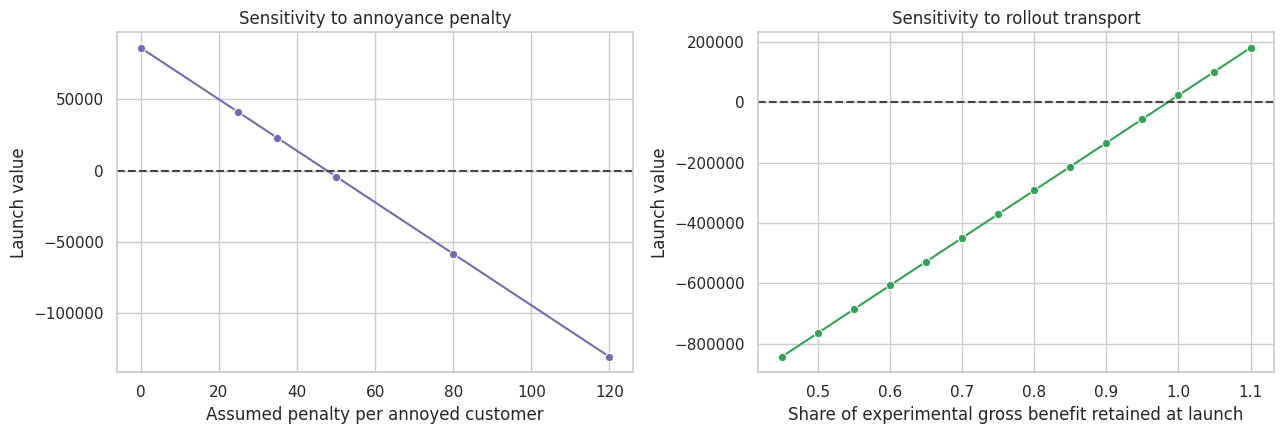

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(
    data=annoyance_sensitivity,
    x="annoyance_penalty",
    y="launch_value",
    marker="o",
    color="#756bb1",
    ax=axes[0],
)
axes[0].axhline(0, color="#444444", linestyle="--")
axes[0].set_title("Sensitivity to annoyance penalty")
axes[0].set_xlabel("Assumed penalty per annoyed customer")
axes[0].set_ylabel("Launch value")

sns.lineplot(
    data=transport_sensitivity,
    x="transport_multiplier",
    y="launch_value",
    marker="o",
    color="#31a354",
    ax=axes[1],
)
axes[1].axhline(0, color="#444444", linestyle="--")
axes[1].set_title("Sensitivity to rollout transport")
axes[1].set_xlabel("Share of experimental gross benefit retained at launch")
axes[1].set_ylabel("Launch value")

plt.tight_layout()
plt.show()


The transport multiplier is a way to make external validity explicit. If the launch team believes the experiment overstates full-rollout benefit, the memo can ask: how much decay would flip the decision?


In [22]:
break_even_transport = (
    fixed_implementation_cost / launch_customers
    + contact_effect
    + discount_effect
    + support_ticket_cost * ticket_effect
    + 35 * annoyance_effect
) / gross_effect

break_even_annoyance_penalty = (
    gross_effect
    - contact_effect
    - discount_effect
    - support_ticket_cost * ticket_effect
    - fixed_implementation_cost / launch_customers
) / max(annoyance_effect, 1e-9)

break_even = pd.Series(
    {
        "Break-even transport multiplier": break_even_transport,
        "Break-even annoyance penalty": break_even_annoyance_penalty,
    }
)

break_even


Break-even transport multiplier    0.985
Break-even annoyance penalty      47.724
dtype: float64

Break-even values are often easier for stakeholders than long statistical explanations:

- If the launch retains less than the break-even share of experimental benefit, do not launch.
- If annoyance is more costly than the break-even penalty, do not launch broadly.


## 10. Risk Register

Decision memos should include a risk register. This is where causal inference meets operations.


In [23]:
risk_register = pd.DataFrame(
    [
        {
            "risk": "Experiment population differs from launch population",
            "why_it_matters": "The average treatment effect may not transport.",
            "mitigation": "Compare covariates; target launch to experiment-like customers; keep a holdout.",
        },
        {
            "risk": "Support team capacity is limited",
            "why_it_matters": "Ticket increases can degrade service quality.",
            "mitigation": "Ramp by risk band; monitor ticket backlog and response time.",
        },
        {
            "risk": "Customers learn to wait for concessions",
            "why_it_matters": "Short-run retention gains may reduce long-run willingness to pay.",
            "mitigation": "Limit discounting; monitor renewal quality and next-cycle churn.",
        },
        {
            "risk": "Low-risk customers are annoyed",
            "why_it_matters": "Average lift can hide avoidable harm.",
            "mitigation": "Exclude low-risk customers from launch policy.",
        },
        {
            "risk": "Effect fades after account managers scale workload",
            "why_it_matters": "Full rollout may reduce treatment fidelity.",
            "mitigation": "Track contact completion, response time, and script adherence.",
        },
    ]
)

risk_register


,risk,why_it_matters,mitigation
0,Experiment population differs from launch popu...,The average treatment effect may not transport.,Compare covariates; target launch to experimen...
1,Support team capacity is limited,Ticket increases can degrade service quality.,Ramp by risk band; monitor ticket backlog and ...
2,Customers learn to wait for concessions,Short-run retention gains may reduce long-run ...,Limit discounting; monitor renewal quality and...
3,Low-risk customers are annoyed,Average lift can hide avoidable harm.,Exclude low-risk customers from launch policy.
4,Effect fades after account managers scale work...,Full rollout may reduce treatment fidelity.,"Track contact completion, response time, and s..."


## 11. Memo Template

A memo should be short enough to read and precise enough to audit. The appendix can hold the full statistical detail.


In [24]:
recommended_policy = policy_values["projected_launch_value"].idxmax()
recommended_value = policy_values.loc[recommended_policy, "projected_launch_value"]
passes_all = bool(guardrail_rules["passes"].all())
decision_word = "Launch targeted policy" if recommended_policy != "Treat none" and recommended_value > 0 else "Do not launch"
if not passes_all and decision_word.startswith("Launch"):
    decision_word = "Launch targeted policy with guardrail constraints"

memo = f'''
### Decision Memo: Retention Outreach Experiment

**Decision:** whether to scale proactive retention outreach for the next renewal cycle.

**Design and estimand:** customer-level randomized experiment estimating the 90-day intention-to-treat effect of assignment to outreach.

**Primary result:** assignment changed net margin by **${net_effect:,.2f}** per eligible customer
with a 95% confidence interval from **${effect_table.loc["Net margin", "ci_lower"]:,.2f}** to
**${effect_table.loc["Net margin", "ci_upper"]:,.2f}**.

**Launch-scale value:** for **{launch_customers:,.0f}** eligible customers and **${fixed_implementation_cost:,.0f}** fixed cost,
expected launch value is **${expected_launch_value:,.0f}**.
The estimated probability of positive launch value is **{prob_positive_value:.1%}**.

**Guardrails:** support tickets changed by **{effect_table.loc["Support tickets", "estimate"]:,.3f}** per customer,
and annoyance changed by **{effect_table.loc["Annoyance rate", "estimate"]:,.3f}**.
The pre-specified guardrail table should govern whether launch is broad or targeted.

**Heterogeneity:** the highest projected value policy is **{recommended_policy}**, with projected value
of **${recommended_value:,.0f}** under current assumptions.

**Recommendation:** **{decision_word}.**

**Rollout conditions:** keep a randomized holdout, exclude groups with weak or negative estimated value,
monitor support load and annoyance weekly, and revisit the decision if rollout benefit falls below
the break-even transport multiplier of **{break_even_transport:.2f}**.
'''

display(Markdown(memo))



### Decision Memo: Retention Outreach Experiment

**Decision:** whether to scale proactive retention outreach for the next renewal cycle.

**Design and estimand:** customer-level randomized experiment estimating the 90-day intention-to-treat effect of assignment to outreach.

**Primary result:** assignment changed net margin by **$2.52** per eligible customer
with a 95% confidence interval from **$0.06** to
**$4.99**.

**Launch-scale value:** for **120,000** eligible customers and **$280,000** fixed cost,
expected launch value is **$22,945**.
The estimated probability of positive launch value is **55.9%**.

**Guardrails:** support tickets changed by **0.034** per customer,
and annoyance changed by **0.015**.
The pre-specified guardrail table should govern whether launch is broad or targeted.

**Heterogeneity:** the highest projected value policy is **Treat medium and high risk**, with projected value
of **$724,058** under current assumptions.

**Recommendation:** **Launch targeted policy with guardrail constraints.**

**Rollout conditions:** keep a randomized holdout, exclude groups with weak or negative estimated value,
monitor support load and annoyance weekly, and revisit the decision if rollout benefit falls below
the break-even transport multiplier of **0.99**.


## 12. What Belongs in the Appendix?

The executive memo should be short. The appendix should make the analysis auditable.


In [25]:
appendix_checklist = pd.DataFrame(
    [
        {
            "section": "Experiment design",
            "include": "Randomization unit, dates, eligibility, sample exclusions, power assumptions.",
        },
        {
            "section": "Estimand",
            "include": "ITT or treatment-on-treated, time horizon, target population, primary outcome definition.",
        },
        {
            "section": "Balance and data quality",
            "include": "Pre-treatment balance, missingness, logging checks, sample ratio mismatch checks.",
        },
        {
            "section": "Primary analysis",
            "include": "Regression formula, standard errors, confidence intervals, raw and adjusted results.",
        },
        {
            "section": "Guardrails",
            "include": "Support, complaints, fairness, operational load, long-run risks.",
        },
        {
            "section": "Heterogeneity",
            "include": "Pre-specified subgroups, treatment policy logic, uncertainty by subgroup.",
        },
        {
            "section": "Sensitivity",
            "include": "Cost assumptions, transport assumptions, break-even thresholds.",
        },
        {
            "section": "Monitoring plan",
            "include": "Holdout design, metrics, review cadence, stop rules.",
        },
    ]
)

appendix_checklist


,section,include
0,Experiment design,"Randomization unit, dates, eligibility, sample..."
1,Estimand,"ITT or treatment-on-treated, time horizon, tar..."
2,Balance and data quality,"Pre-treatment balance, missingness, logging ch..."
3,Primary analysis,"Regression formula, standard errors, confidenc..."
4,Guardrails,"Support, complaints, fairness, operational loa..."
5,Heterogeneity,"Pre-specified subgroups, treatment policy logi..."
6,Sensitivity,"Cost assumptions, transport assumptions, break..."
7,Monitoring plan,"Holdout design, metrics, review cadence, stop ..."


## 13. Common Memo Failure Modes

- **P-value memo:** treats statistical significance as the decision.
- **Metric-only memo:** reports lift but ignores costs and guardrails.
- **Point-estimate memo:** hides uncertainty and downside risk.
- **Average-only memo:** ignores segments where the intervention harms or wastes resources.
- **Post-hoc memo:** changes the success rule after seeing results.
- **Untransported memo:** assumes the experiment effect will hold under full rollout without argument.
- **No-monitoring memo:** recommends launch without saying what evidence would trigger rollback.


## 14. Exercises

1. Change the fixed implementation cost. At what cost does the recommendation change?
2. Change the annoyance penalty. Which rollout policy becomes best?
3. Recompute policy value using only groups whose lower confidence bound is above zero.
4. Add a fairness guardrail by region. Does the recommendation change?
5. Assume the experiment effect decays by 40% at launch. Should the team still roll out?
6. Write a two-paragraph executive memo for a non-technical leader using the results in this notebook.


## 15. Key Takeaways

- The causal estimate is an input to the decision, not the decision itself.
- A useful memo states the decision, estimand, design, primary effect, uncertainty, guardrails, economics, heterogeneity, and monitoring plan.
- Launch-scale value requires explicit assumptions about population size, fixed cost, variable cost, and transport from experiment to rollout.
- Guardrails can turn a broad launch into a targeted launch or a hold decision.
- Heterogeneity is useful when it maps to a feasible pre-treatment targeting policy.
- Sensitivity analysis is not a weakness. It is how the memo earns trust.


## References

Angrist, J. D., Imbens, G. W., & Rubin, D. B. (1996). Identification of causal effects using instrumental variables. *Journal of the American Statistical Association, 91*(434), 444-455. https://doi.org/10.1080/01621459.1996.10476902

Callaway, B. (2022). Difference-in-differences for policy evaluation. *arXiv*. https://doi.org/10.48550/arxiv.2203.15646

Deaton, A., & Cartwright, N. (2018). Understanding and misunderstanding randomized controlled trials. *Social Science & Medicine, 210*, 2-21. https://doi.org/10.1016/j.socscimed.2017.12.005

Imbens, G. W. (2014). Instrumental variables: An econometrician's perspective. *Statistical Science, 29*(3), 323-358. https://doi.org/10.1214/14-STS480
